In [33]:
from typing import TypedDict , List

from langgraph.graph import StateGraph,START,END



In [34]:
class AgentState(TypedDict):  #our state schema
    num1: int
    num2: int
    ope : str
    result : int

In [35]:
def adder(state: AgentState)-> AgentState:
    """this node adds 2 numbers"""

    state["result"] = state["num1"] + state["num2"]

    return state

def subractor(state: AgentState)-> AgentState:
    """this node subtracts 2 numbers"""

    state["result"] = state["num1"] - state["num2"]

    return state

In [36]:
def decide_node(state: AgentState)-> AgentState:
    """ this node will decide which node to run next
    """

    if state["ope"] == "+":
        return "addition_operation"
    elif state["ope"] == "-":
        return "subtraction_operation"

In [37]:
graph = StateGraph(
    AgentState
)

 #passthrough func
graph.add_node("addition_node",adder)
graph.add_node("subtraction_node",subractor)
graph.add_node("router",lambda state:state)


graph.add_edge(START,"router")
graph.add_conditional_edges(
    "router",
    decide_node,
    {    #   "edges" : node"
        "addition_operation":"addition_node",
        "subtraction_operation":"subtraction_node",
        
    }
)

graph.add_edge("addition_node",END)
graph.add_edge("subtraction_node",END)

app = graph.compile()


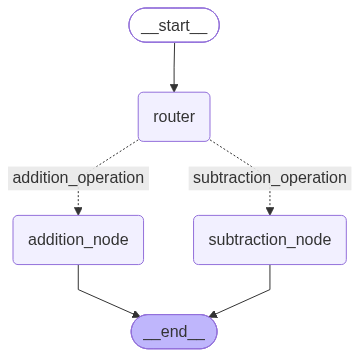

In [38]:
from IPython.display import display,Image
display(Image(app.get_graph().draw_mermaid_png()))

In [40]:
ans = AgentState(num1=2,num2=3,ope="-")
print(app.invoke(ans))

{'num1': 2, 'num2': 3, 'ope': '-', 'result': -1}


# exercise